<a href="https://colab.research.google.com/github/suhyeon03/DeepLearning/blob/main/2_%EC%B5%9C%EB%8C%80_%EA%B0%80%EB%8A%A5%EB%8F%84_%EC%B6%94%EC%A0%95ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* 세상에는 정규 분포와 비슷한 분포가 많다는 사실을 이야기했다.
* 이번 장에서는 그러한 분포에 대해 정규 분포를 적합 시키는 방법을 알아본다.
* 그 방법은 바로 '최대 가능도 추정(MLE)'이다.


# 생성 모델 개요
* 생성 모델의 목표는 무엇이고 어떻게 만드는지 알아보며 생성 모델을 이해한다.

## 생성 모델의 목표

* 생성모델의 목표는 특정 데이터 x의 확률 분포 p(x)를 모델링(수식으로)한 다음, 마치 그 집단에서 선택된 것 같은 유사 데이터를 새롭게 생성하는 것이다.
* 다르게 표현하면, 실제 데이터와 구분하기 어려운 데이터를 새로 생성해 내는 모델을 만드는 것이 목표이다.
* 예를 들어 어떤 집단의 키 확률분포를 정규 분포로 표현했다면 이는 훌륭한 생성 모델이다.
* 예를 들어 평균이 172.7이고, 표준편차가 4.8인 정규분포라고 한다.
* 이렇게 집단의 특징을 모델링하는 것이 생성 모델의 목표이다.
* 확률분포의 매개변수(평균, 표준편차)를 추정해야하고 적절한 매개변수를 설정하는 작업을 매개변수 추정 또는 추론이라고 한다.

## 모집단과 샘플
* 모집단은 주로 통계학에서 쓰이고, 대상의 전체 집합을 말한다.
* 일반적으로 모집단의 규모는 방대하다. 통계학에서는 제한된 수의 샘플만으로 모집단의 특성을 추정하는 일을 한다.
* 생성 모델에서도 샘플을 사용하여 모집단을 추정한다.
* 생성 모델이라는 맥락에서 모집단은 '샘플을 뒷받침하는 확률 분포'이다.
* 그 확률 분포를 모집단 분포라고 한다.

* 모집단 분포인 p*(x)를 얻을 수 있다면 이상적이겠지만, 현실적으로 모집단 분포를 직접 알 수는 없다.
* 그래서 샘플을 바탕으로 모집단 분포를 추정한다.
* 일반적으로 두가지 작업을 수행한다.
  * 모델링 : 모집단 분포를 '매개변수로 조정 가능한 확률 분포'로 비슷하게 표현할 수 있다고 가정한다.
  * 매개변수 추정 : 모델링 결과로 만들어진 확률 분포가 샘플 데이터에 부합하도록 매개변수를 추정한다.
* 이처럼 모델링과 매개변수 추정 작업을 통해 생성 모델이 만들어진다.
* 첫 번째 모델링에서는 정규분포와 같이 매개변수로 제어할 수 있는 확률 분포를 설정한다.
* 그런 다음 매개변수 추정에서는 샘플과 가장 잘 부합하도록 매개변수를 조정한다.
* 이떄 최대 가능도 추정 기법을 사용한다.


# 실제 데이터로 생성 모델 구현
## 키 데이터 셋 불러오기

In [1]:
!git clone https://github.com/Rucious-Aladdin/DLFromScratch5.git

Cloning into 'DLFromScratch5'...
remote: Enumerating objects: 162, done.
remote: Counting objects: 100% (162/162), done.
remote: Compressing objects: 100% (126/126), done.
remote: Total 162 (delta 39), reused 144 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (162/162), 27.22 MiB | 19.01 MiB/s, done.
Resolving deltas: 100% (39/39), done.


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt

path = '/content/DLFromScratch5/Chapter02/height.txt'
xs = np.loadtxt(path) # 파일 불러오기
print(xs.shape) # (25000,)

(25000,)


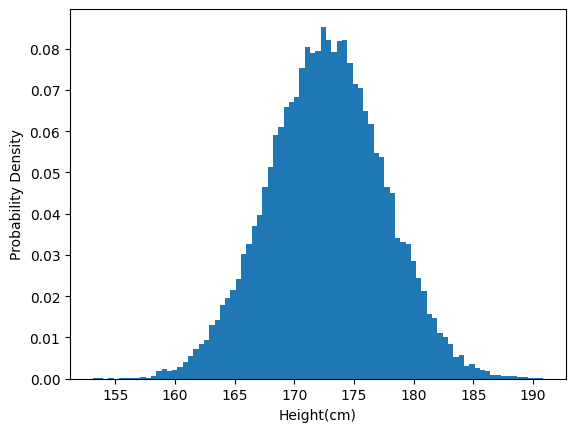

In [5]:
plt.hist(xs, bins='auto', density=True)
plt.xlabel('Height(cm)')
plt.ylabel('Probability Density')
plt.show()

## 정규 분포를 따르는 생성 모델
  * 모델링 : 키 데이터가 정규 분포라고 가정
  * 매개변수 추정 : 샘플을 기반으로 정규 분포의 매개변수를 추정
* 이 두 작업을 통해 생성 모델을 만들 것이다. 첫 번째 작업인 모데링은 앞 절에서 이미 완료 했다.
* 다음은 매개변수 추정 차례이다. 구체적으로 할 일은 샘플을 바탕으로 정규 분포의 매개변수를 추정하는 것이다.

* 매개변수를 추정하는 방법으로 최대 가능도 추정이 있다.
* 최대 가능도 추정을 이용하여 샘플에 가장 잘 들어맞는 매개변수를 추정할 수 있다.
* 결론부터 말하면 정규 분포의 매개변수는 '샘플의 평균'과 '샘플의 표준 편차'이다.
* 먼저 샘플의 평균과 표준편차를 구한다.

In [6]:
# xs는 25000개의 원소로 이루어진 1차원 배열
mu = np.mean(xs)
sigma = np.std(xs)

print(mu)
print(sigma)

172.70250853667997
4.830167473396299


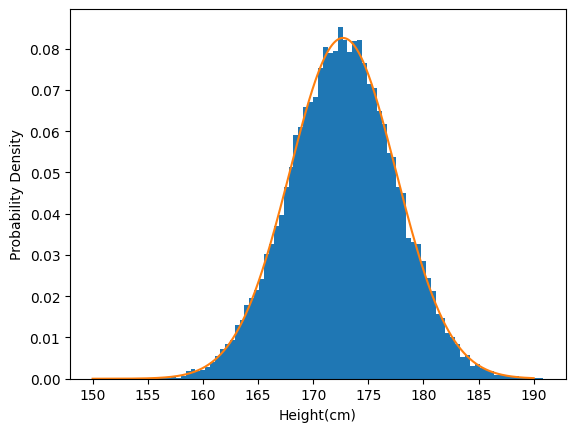

In [7]:
# 앞서 살펴본 히스토그램에 정규 분포 그래프를 덧 씌워본다.

mu = np.mean(xs)
sigma = np.std(xs)

# 정규 분포 함수
def normal(x, mu, sigma):
  y = 1 / (np.sqrt(2 * np.pi) * sigma) * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))
  return y

x = np.linspace(150, 190, 1000)
y = normal(x, mu, sigma)

# 그래프 그리기
plt.hist(xs, bins='auto', density=True)
plt.plot(x, y)
plt.xlabel('Height(cm)')
plt.ylabel('Probability Density')
plt.show()

# 최대 가능도 추정 이론

* 앞 절에서는 샘플로부터 정규 분포의 매개변수를 추정했다.
* 구체적으로 N개의 관측 데이터 {x1, x2, x3, xn}을 얻었을 때, 다음 식에 따라 매개변수를 추정했다.

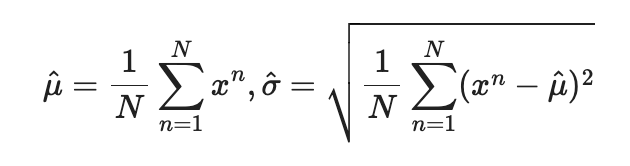

* 정규 분포의 평균을 u헷기호로, 표준편차 a헷기호로 표현한다.
* 이 식과 같이 u헷은 샘플의 평균으로, a헷은 샘플의 표준편차로 추정한다.
* 그렇다면 이 식들이 성립함은 어떻게 알 수 있을까?
* 열쇠는 최대 가능도 추정에 있다.

## 가능도 최대화
* 매개변수 세타에 의해 모양이 결정되는 확률 분포가 있다고하자.
* 매개변수가 세타라면, 데이터 x를 얻을 수 있는 확률 밀도는 p(x;세타)로 표현한다.
* 다음으로 샘플 D = {x1, x2, x3, xn}을 얻는 경우를 생각해보자.
* 각 데이터는 확률 분포 p(x;세타)에 따라 독립적으로 생성된다고 가정한다.
* 이때 샘플 D를 얻을 수 있는 확률 밀도는 다음 식으로 표현할 수 있다.

* N개의 data를 얻을수 있는 확률 밀도는 각 데이터의 확률 밀도의 곱으로 표현된다.
* 각 데이터는 독립적으로 생성되기 때문이다.
* p(D;세타)는 매개변수를 세타로 설정했을 때 샘플 D를 얻을 수 있는 확률 밀도를 뜻한다.
* 이러한 p(D;세타)를 '세타를 인수로 받는 함수'로 간주하여 다음과 같은 식을 정의할 수도 있다.

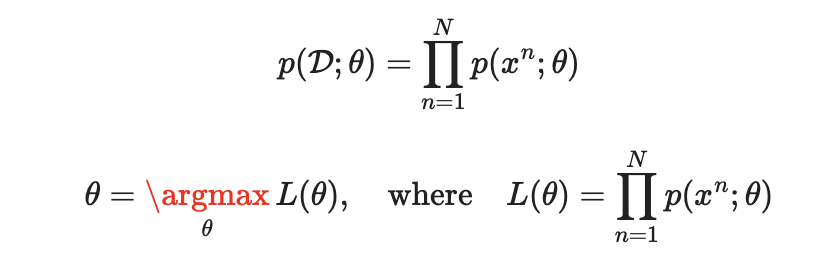

* L(세타) = p(D;세타)
* 이 L을 가능도 또는 가능도 함수라고 한다.
* 가능도란 매개변수 세타를 인수로 받는 함수이며, 어떤 매개변수 세타에 대해 샘플 D가 일어날 가능성을 확률 밀도로 표현한다.
* 일반적으로 가능도는 p(D;세타)를 말한다.

* 최대 가능도 추정은 가능도 p(D;세타)를 최대화하려는 매개변수 세타를 찾는 기법이다.
* 예컨대 가능도를 최대화하는 매개변수를 세타헷이라고 하면, 매개변수가 세타헷일 때 샘플이 관찰될 확률이 가장 높다.
* 즉 세타헷일 때 모델이 샘플에 가장 잘 맞는다는 뜻이다.
* 일반적으로 로그를 붙여 로그 가능도를 최대화한다. - 계산이 편함

## 미분을 사용하여 최댓값 찾기

* 최대값을 구할 때 중요한 것은 미분이다.
* 함수의 미분을 구해 0이 되는 곳에 최댓값이 존재함을 알 수 있다. (예 2차 함수)
* 이처럼 수식을 풀어 해를 구하는 것을 해석적으로 풀 수 있다고 하고 닫힌 해를 구할 수 있다고도 한다.

* 로그 가능도 역시 매개변수 세타의 미분을 구하고 이를 0으로 설정하여 해석적으로 풀 수 있다. (증명 생략)
* 최대 가능도 추정에 의해 정규 분포의 매개변수를 알 수 있게된다.

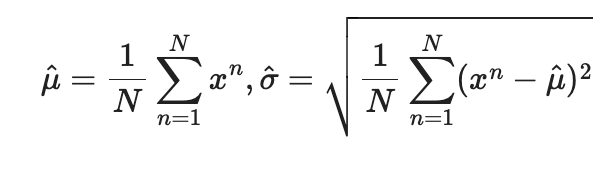

# 생성 모델의 용도

* 모델링 : 키 데이터가 정규분포라 가정
* 매개변수 추정 : 최대 가능도 추정으로 정규 분포의 매개변수를 추정

In [8]:
import os
import numpy as np
import matplotlib.pyplot as plt

mu = np.mean(xs)
sigma = np.std(xs)

print(mu)
print(sigma)


172.70250853667997
4.830167473396299


* 이 코드를 실행하면 평균이 172.7이고 표준 편차가 4.8인 정규 분포를 얻는다.
* 참고로 매개변수 추정을 학습이라고도 한다. 즉 이상으로 생성 모델의 학습이 완료되었다.

## 새로운 데이터 생성

* 생성 모델을 사용하면 새로운 데이터를 생성할 수 있다.
* 앞에서 키 데이터 셋을 이용하여 키를 평균 172.7, 표준 편차 4.8의 정규 분포로 모델링할 수 있었다.
* 이제 이 정규 분포로부터 새로운 데이터를 생성할 수 있다.

In [10]:
np.random.normal(loc=0.0, scale=1.0, size=None)

1.5852832347014572

* loc는 평균, scale은 표준편차에 해당한다.
* size는 생성할 값의 개수이며, 따로 지정하지 않으면 기본값인 None으로 설정된다.
* None이면 1개만 생성한다. 다음 코드 예처럼 이 함수를 사용하면 새로운 키 데이터 샘플을 얻을 수 있다.

In [11]:
sample = np.random.normal(mu, sigma)
print(sample)

176.13673503787018


* 이제 새로운 데이터를 생성할 수 있게 되었다. 새로운 데이터이면서 키 데이터셋의 특징을 지니고 있다.
* 다음으로 생성 모델에서 1만 개의 샘플을 추출하여, 즉 1만 개의 새로운 데이터를 생서하여 그 분포를 살펴보자.

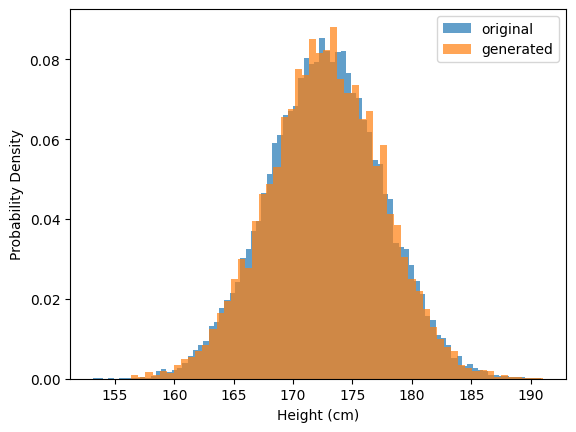

In [13]:
path = '/content/DLFromScratch5/Chapter02/height.txt'
xs  = np.loadtxt(path)

mu = np.mean(xs)
sigma = np.std(xs)
samples = np.random.normal(mu, sigma, 10000)

plt.hist(xs, bins="auto", density=True, alpha=.7, label="original")
plt.hist(samples, bins="auto", density=True, alpha=.7, label="generated")
plt.xlabel('Height (cm)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

* 보다시피 두 분포가 거의 일치한다. 우리의 생성 모델이 관측 데이터의 특징을 잘 포착하여 비슷한 데이터를 새로 생성할 수 있다는 뜻이다.
* 이번에는 '키'라는 1차원의 단순한 데이터를 다뤗지만 다음 장에서 소개할 복잡한 생성 모델이라면 이미지와 같은 다차원 데이터도 생성할 수 있다.
* 적절한 딥러닝 모델을 고안하고 대량의 데이터로 학습시켜야 한다.

# 확률 계산

* 확률 분포를 알면 어떤 값이 얼마나 발생하기 쉬운지를 알 수 있다.
* 연속 확률 분포에서 확률을 구하려면 확률 밀도 p(x)를 적분해야한다.
* 정규 분포라면 적분을 해석적으로, 즉 수식을 풀어 구할 수 잇다.
* 해석적으로 구하기 어려운 경우에도 몬테카를로 방법을 이용하여 근사적으로 구한다.

In [19]:
from scipy.stats import norm

norm.cdf(x, loc=0, scale=1)

np.float64(0.8413447460685429)

* cdf()함수의 인수 중 loc는 평균, scale은 표준편차이다. x에 적절한 스칼라값을 입력하면 'x 이하의 값이 발생할 확률'을 반환한다.

In [15]:
from scipy.stats import norm

x = 1.0
p = norm.cdf(x, loc=0, scale=1)
print(p)

0.8413447460685429


* 코드를 실행하면 0.8413이라고 나온다. 이값은 x<= 1 구간에서 표준 정규 분포의 면적이며 그 값은 곧 x <= 1이 될 확률을 뜻한다.
* cdf()함수를 이용하면 키 데이터의 정규 분포에 대해서도 확률을 계산할 수 있다.
* 예를 들어 다음과 같은 코드를 작성할 수 있다.

In [20]:
import numpy as np
from scipy.stats import norm

xs = np.loadtxt(path)
mu = np.mean(xs)
sigma = np.std(xs)

p1 = norm.cdf(160, loc=mu, scale=sigma)
print(f"p(x <= 160): {p1}")

p2 = norm.cdf(180, loc=mu, scale=sigma)
print(f"p(x > 170): {1-p2}")

p(x <= 160): 0.004271406830855
p(x > 170): 0.06541774339950823


* 이렇게 산출된 확률은 다양한 의사결정에 활용할 수 있다.
* 키를 예로 들면, 키의 예상 범위를 확률에 기초해 결정한 다음, 문 높이를 몇 cm로 하면 몇 %의 사람이 허리를 굽히지 않고 드나들 수 있는지를 정량적으로 계산할 수 있다.